In [2]:
# CELL 1 — Imports + GPU check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM,
    Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix)

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ GPUs found : {tf.config.list_physical_devices('GPU')}")

2026-04-10 04:21:17.452122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775794877.652435      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775794877.717309      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775794878.204853      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775794878.204902      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775794878.204909      55 computation_placer.cc:177] computation placer alr

✅ TensorFlow : 2.19.0
✅ GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# CELL 2 — Load preprocessed data
print("Searching for Day 2 files...")
found_path = None

for root, dirs, files in os.walk('/kaggle/'):
    if 'X_train.npy' in files:
        found_path = root
        print(f"✅ Found at: {root}")
        break

if found_path is None:
    print("❌ Add day-02-preprocessing output as input!")
else:
    X_train = np.load(f'{found_path}/X_train.npy')
    X_test  = np.load(f'{found_path}/X_test.npy')
    y_train = np.load(f'{found_path}/y_train.npy')
    y_test  = np.load(f'{found_path}/y_test.npy')

    with open(f'{found_path}/label_encoder.pkl','rb') as f:
        le = pickle.load(f)
    with open(f'{found_path}/top_features.pkl','rb') as f:
        top_features = pickle.load(f)

    n_classes  = len(le.classes_)
    n_features = X_train.shape[1]

    print(f"✅ Data loaded!")
    print(f"   X_train  : {X_train.shape}")
    print(f"   X_test   : {X_test.shape}")
    print(f"   Classes  : {n_classes}")
    print(f"   Features : {n_features}")

Searching for Day 2 files...
✅ Found at: /kaggle/input/notebooks/mchandana086/day-02-preprocessing
✅ Data loaded!
   X_train  : (34182810, 20)
   X_test   : (419362, 20)
   Classes  : 27
   Features : 20


In [4]:
# CELL 3 — Reshape for CNN-LSTM
SAMPLE_SIZE = 500_000
print(f"Using {SAMPLE_SIZE:,} training samples")

# Random sample from 34M
idx = np.random.choice(
    len(X_train), SAMPLE_SIZE, replace=False)
X_train_s = X_train[idx]
y_train_s = y_train[idx]

# Reshape to 3D: (samples, features, 1)
X_train_r = X_train_s.reshape(
    X_train_s.shape[0], n_features, 1)
X_test_r  = X_test.reshape(
    X_test.shape[0], n_features, 1)

# One-hot encode labels
y_train_cat = to_categorical(
    y_train_s, num_classes=n_classes)
y_test_cat  = to_categorical(
    y_test, num_classes=n_classes)

print(f"✅ Reshaped!")
print(f"   X_train_r : {X_train_r.shape}")
print(f"   X_test_r  : {X_test_r.shape}")
print(f"   y_train   : {y_train_cat.shape}")

Using 500,000 training samples
✅ Reshaped!
   X_train_r : (500000, 20, 1)
   X_test_r  : (419362, 20, 1)
   y_train   : (500000, 27)


In [5]:
# CELL 4 — Build CNN-LSTM with 2 GPUs
strategy = tf.distribute.MirroredStrategy()
print(f"✅ Using {strategy.num_replicas_in_sync} GPU(s)")

with strategy.scope():
    model = Sequential([

        # CNN Block 1
        Conv1D(filters=64, kernel_size=3,
               activation='relu', padding='same',
               input_shape=(n_features, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, padding='same'),

        # CNN Block 2
        Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, padding='same'),

        # LSTM Block
        LSTM(units=128, return_sequences=True,
             dropout=0.2, recurrent_dropout=0.2),
        LSTM(units=64, return_sequences=False,
             dropout=0.2, recurrent_dropout=0.2),

        # Output
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])

model.summary()
print(f"\n✅ Model built!")
print(f"   Total params : {model.count_params():,}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1775794944.865850      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775794944.872304      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Using 2 GPU(s)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,635 (830.61 KB)

 Trainable params: 212,251 (829.11 KB)

 Non-trainable params: 384 (1.50 KB)


✅ Model built!
   Total params : 212,635


In [6]:
# CELL 5 — Train CNN-LSTM
print("Training CNN-LSTM...")
print("Takes 15-25 minutes on 2 GPUs")
print("=" * 45)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1),
    ModelCheckpoint(
        '/kaggle/working/cnn_lstm_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1)
]

history = model.fit(
    X_train_r, y_train_cat,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

best_val = max(history.history['val_accuracy'])
print(f"\n✅ Training complete!")
print(f"   Best val accuracy: {best_val:.4f} ({best_val*100:.2f}%)")

Training CNN-LSTM...
Takes 15-25 minutes on 2 GPUs
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/rep

I0000 00:00:1775794956.501744     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775794956.716074     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6618 - loss: 1.0159INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.82950, saving model to /kaggle/working/cnn_lstm_best.h5


879/879 ━━━━━━━━━━━━━━━━━━━━ 66s 60ms/step - accuracy: 0.6619 - loss: 1.0154 - val_accuracy: 0.8295 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 2/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8420 - loss: 0.3524
Epoch 2: val_accuracy improved from 0.82950 to 0.86046, saving model to /kaggle/working/cnn_lstm_best.h5


879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8420 - loss: 0.3523 - val_accuracy: 0.8605 - val_loss: 0.2888 - learning_rate: 0.0010
Epoch 3/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8612 - loss: 0.2958
Epoch 3: val_accuracy improved from 0.86046 to 0.86612, saving model to /kaggle/working/cnn_lstm_best.h5


...

879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.8676 - loss: 0.2697 - val_accuracy: 0.8714 - val_loss: 0.2618 - learning_rate: 5.0000e-04
Epoch 15/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8679 - loss: 0.2688
Epoch 15: val_accuracy did not improve from 0.87138
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8679 - loss: 0.2688 - val_accuracy: 0.8682 - val_loss: 0.2794 - learning_rate: 5.0000e-04
Epoch 16/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8687 - loss: 0.2685
Epoch 16: val_accuracy did not improve from 0.87138
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8687 - loss: 0.2685 - val_accuracy: 0.8710 - val_loss: 0.2638 - learning_rate: 5.0000e-04
Epoch 17/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8672 - loss: 0.2697
Epoch 17: val_accuracy did not improve from 0.87138

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8672

879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8694 - loss: 0.2669 - val_accuracy: 0.8718 - val_loss: 0.2603 - learning_rate: 2.5000e-04
Epoch 19/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8690 - loss: 0.2668
Epoch 19: val_accuracy improved from 0.87184 to 0.87188, saving model to /kaggle/working/cnn_lstm_best.h5


879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8690 - loss: 0.2668 - val_accuracy: 0.8719 - val_loss: 0.2597 - learning_rate: 2.5000e-04
Epoch 20/30
878/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8697 - loss: 0.2648
Epoch 20: val_accuracy did not improve from 0.87188
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8697 - loss: 0.2648 - val_accuracy: 0.8689 - val_loss: 0.2599 - learning_rate: 2.5000e-04
Epoch 21/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8689 - loss: 0.2652
Epoch 21: val_accuracy did not improve from 0.87188
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8689 - loss: 0.2652 - val_accuracy: 0.8717 - val_loss: 0.2594 - learning_rate: 2.5000e-04
Epoch 22/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8698 - loss: 0.2644
Epoch 22: val_accuracy did not improve from 0.87188
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8698 - loss: 0.2644 - val_accuracy: 0.8716 - val_loss: 0.2598 - learning_rate: 2.5

879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8701 - loss: 0.2628 - val_accuracy: 0.8723 - val_loss: 0.2580 - learning_rate: 1.2500e-04
Epoch 29/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8704 - loss: 0.2629
Epoch 29: val_accuracy improved from 0.87230 to 0.87232, saving model to /kaggle/working/cnn_lstm_best.h5


879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8704 - loss: 0.2629 - val_accuracy: 0.8723 - val_loss: 0.2588 - learning_rate: 1.2500e-04
Epoch 30/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8699 - loss: 0.2632
Epoch 30: val_accuracy did not improve from 0.87232
879/879 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.8699 - loss: 0.2632 - val_accuracy: 0.8721 - val_loss: 0.2582 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 28.

✅ Training complete!
   Best val accuracy: 0.8723 (87.23%)


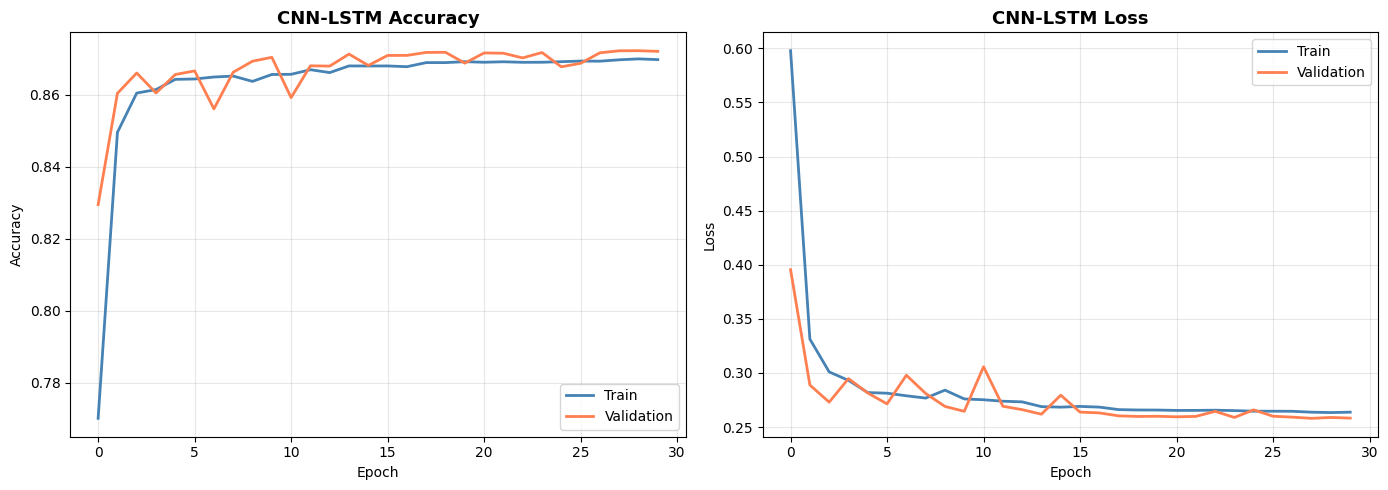

✅ Training curves saved!


In [7]:
# CELL 6 — Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],
         label='Train', color='steelblue', linewidth=2)
ax1.plot(history.history['val_accuracy'],
         label='Validation', color='coral', linewidth=2)
ax1.set_title('CNN-LSTM Accuracy',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],
         label='Train', color='steelblue', linewidth=2)
ax2.plot(history.history['val_loss'],
         label='Validation', color='coral', linewidth=2)
ax2.set_title('CNN-LSTM Loss',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/cnn_lstm_training.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

In [12]:
# CELL 7 — Evaluate on test set
print("Evaluating on test set...")

y_pred_prob = model.predict(X_test_r, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred,
               average='weighted',
               zero_division=0)

print(f"\n{'='*50}")
print(f"CNN-LSTM FINAL RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    zero_division=0))

Evaluating on test set...
13106/13106 ━━━━━━━━━━━━━━━━━━━━ 180s 14ms/step

CNN-LSTM FINAL RESULTS
  Accuracy  : 0.9850 (98.50%)
  F1-Score  : 0.9877

Classification Report:
                                        precision    recall  f1-score   support

                                BENIGN       1.00      0.99      1.00    316508
                                Botnet       0.37      1.00      0.54       147
                    Botnet - Attempted       0.43      1.00      0.60       814
                                  DDoS       1.00      1.00      1.00     19029
                         DoS GoldenEye       0.32      0.99      0.48      1514
             DoS GoldenEye - Attempted       0.33      1.00      0.49        16
                              DoS Hulk       1.00      0.90      0.95     31694
                  DoS Hulk - Attempted       0.00      0.00      0.00       116
                      DoS Slowhttptest       0.97      1.00      0.98       348
          DoS Slowhttptest

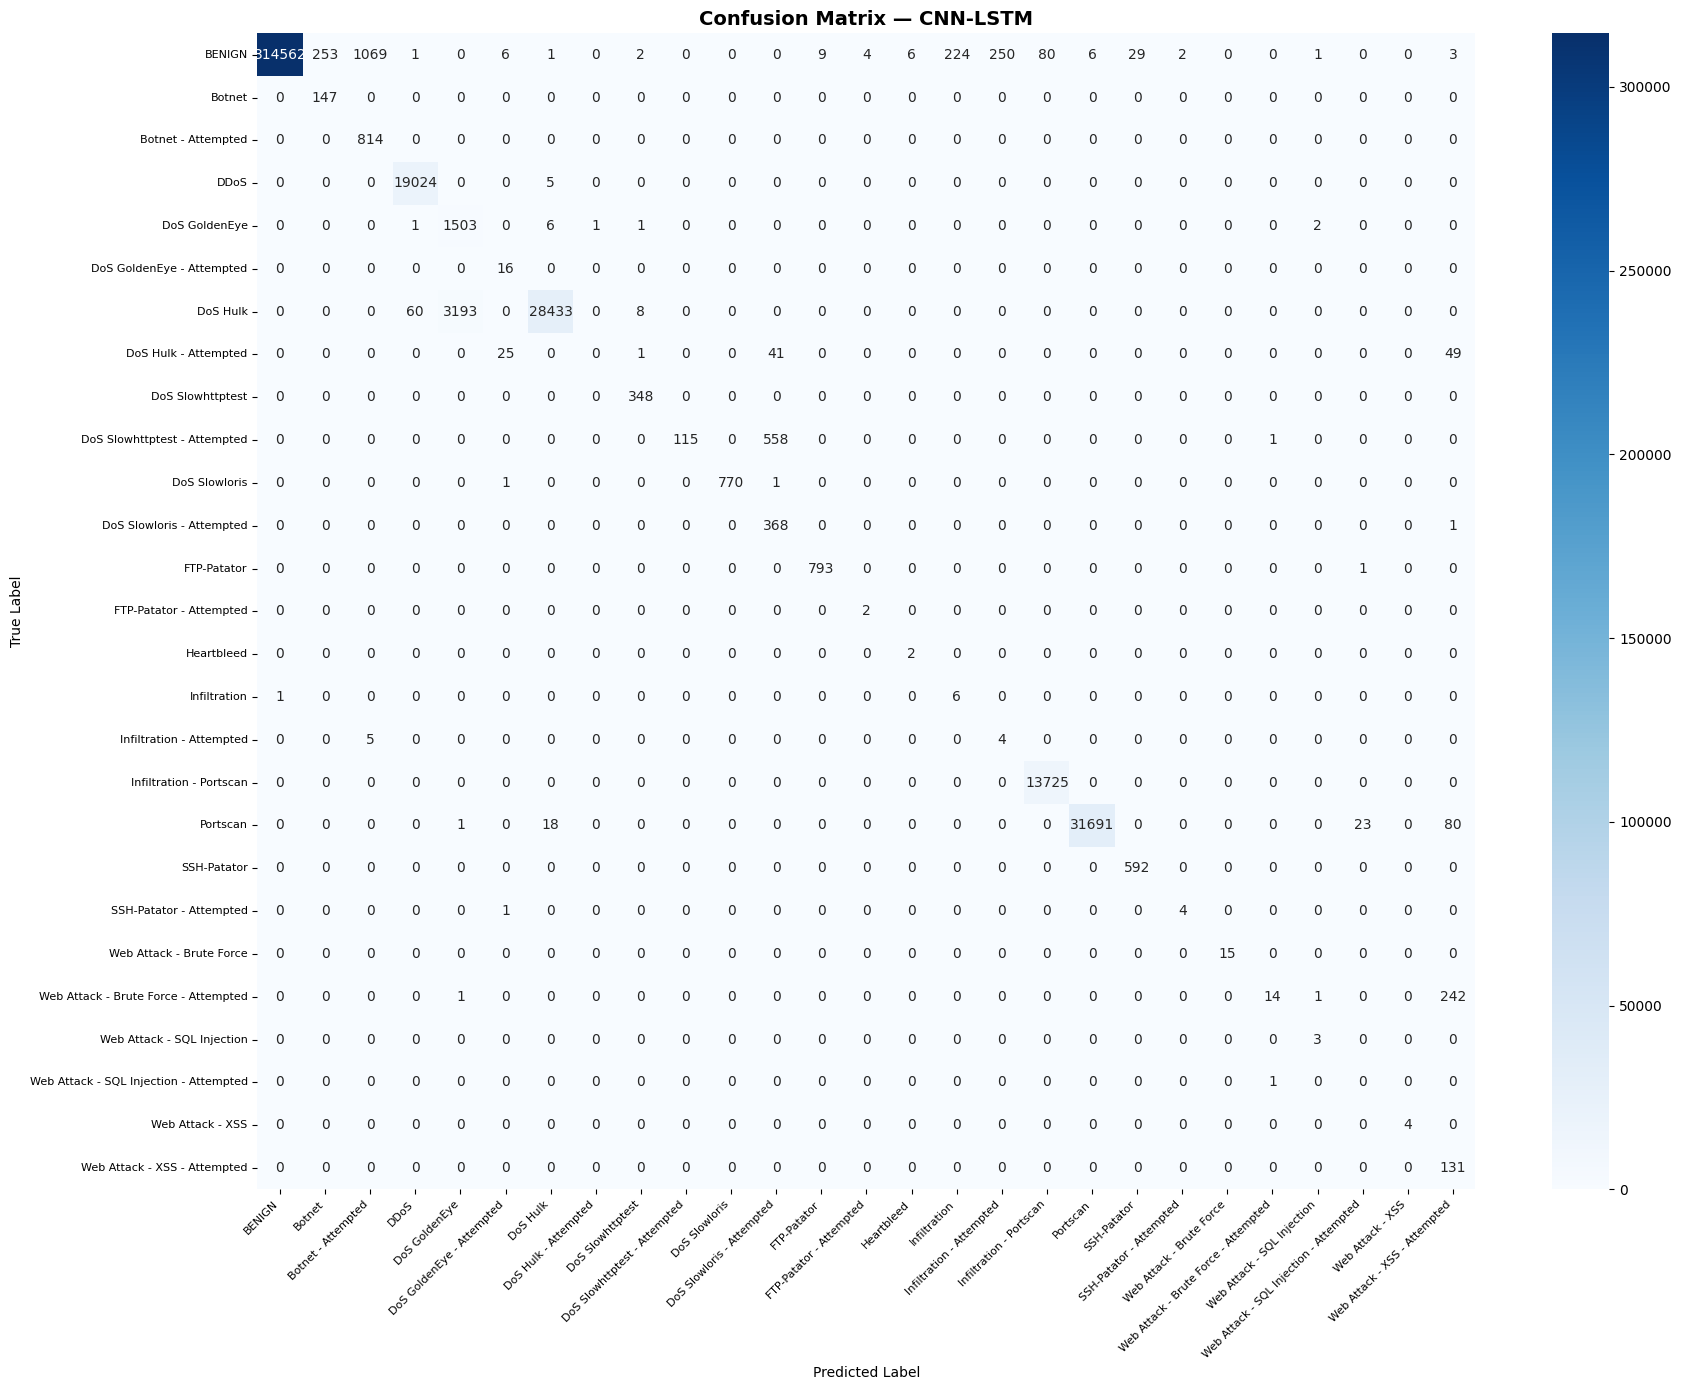

✅ Confusion matrix saved!


In [13]:
# CELL 8 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — CNN-LSTM',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/cnn_lstm_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

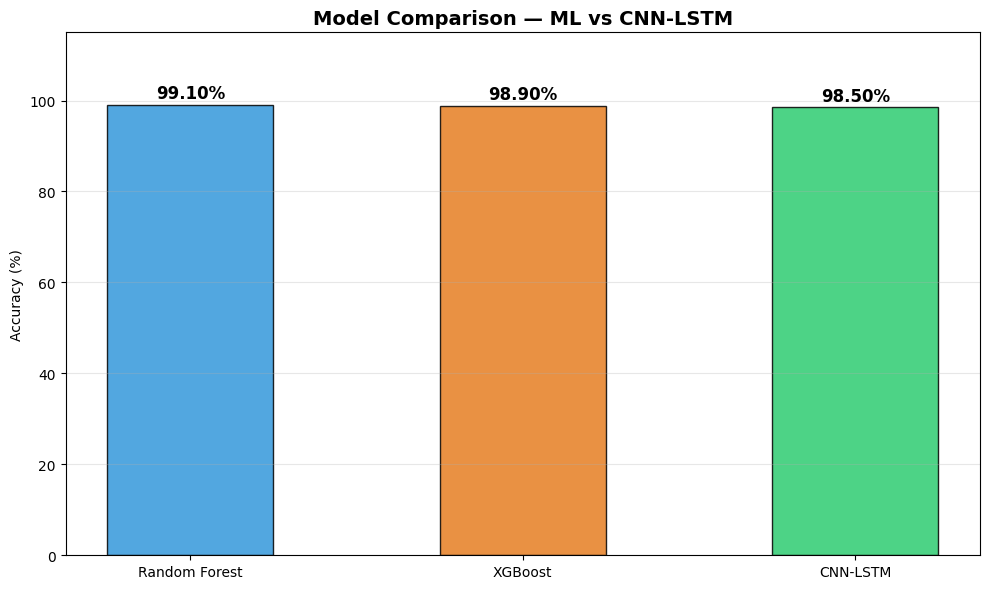

✅ Comparison chart saved!


In [14]:
# CELL 9 — Compare CNN-LSTM vs ML baselines
# ← Replace with your actual Day 3 numbers
rf_acc  = 0.991   # your RF accuracy
xgb_acc = 0.989   # your XGBoost accuracy

models = ['Random Forest', 'XGBoost', 'CNN-LSTM']
accs   = [rf_acc,  xgb_acc,  acc]
colors = ['#3498DB','#E67E22','#2ECC71']

plt.figure(figsize=(10, 6))
bars = plt.bar(models,
               [a*100 for a in accs],
               color=colors,
               edgecolor='black',
               alpha=0.85,
               width=0.5)

for bar, a in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{a*100:.2f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold')

plt.title('Model Comparison — ML vs CNN-LSTM',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [15]:
# CELL 10 — Save all results
results = {
    'model'         : 'CNN-LSTM',
    'accuracy'      : float(acc),
    'f1_score'      : float(f1),
    'epochs_trained': len(history.history['accuracy']),
    'best_val_acc'  : float(max(
                      history.history['val_accuracy'])),
    'sample_size'   : SAMPLE_SIZE,
    'n_classes'     : n_classes,
    'n_features'    : n_features
}

with open('/kaggle/working/cnn_lstm_results.json',
          'w') as f:
    json.dump(results, f, indent=2)

print("✅ ALL FILES SAVED:")
for fname in sorted(os.listdir('/kaggle/working/')):
    if not fname.startswith('.'):
        size = os.path.getsize(
               f'/kaggle/working/{fname}'
               ) // 1024 // 1024
        print(f"  └── {fname:<40s} {size:>4} MB")

print(f"\n🎉 DAY 4 CNN-LSTM COMPLETE!")
print(f"   Accuracy  : {acc*100:.2f}%")
print(f"   F1-Score  : {f1:.4f}")
print(f"\n✅ Ready for Day 5 — Autoencoder!")

✅ ALL FILES SAVED:
  └── cnn_lstm_best.h5                            2 MB
  └── cnn_lstm_confusion.png                      0 MB
  └── cnn_lstm_results.json                       0 MB
  └── cnn_lstm_training.png                       0 MB
  └── ml_baseline_results.json                    0 MB
  └── model_comparison.png                        0 MB

🎉 DAY 4 CNN-LSTM COMPLETE!
   Accuracy  : 98.50%
   F1-Score  : 0.9877

✅ Ready for Day 5 — Autoencoder!
